In [2]:
import pandas as pd
import matplotlib as mt

In [3]:
HR = pd.read_csv('HR_capstone_dataset.csv')
HR

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


In [4]:
HR.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [5]:
HR.isna().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64

In [6]:
HR.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

In [7]:
HR_DEPARTMENT_SALARY_MEAN = HR.groupby(['Department', 'salary'])[['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'promotion_last_5years']] \
    .mean() \
    .head()

HR_DEPARTMENT_SALARY_MEAN


satisfaction_level  last_evaluation  number_project  \
Department salary                                                        
IT         high              0.638193         0.716627        3.867470   
           low               0.610099         0.715665        3.794745   
           medium            0.624187         0.718187        3.833645   
RandD      high              0.586667         0.700588        3.764706   
           low               0.623929         0.714176        3.804945   

                   average_montly_hours  time_spend_company  \
Department salary                                             
IT         high              194.927711            3.072289   
           low               201.382594            3.438424   
           medium            204.295327            3.564486   
RandD      high              199.745098            3.529412   
           low               198.747253            3.381868   

                   promotion_last_5years  
Department salary                         
IT         high                 0.000000  
           low                  0.003284  
           medium               0.001869  
RandD      high                 0.019608  
           low                  0.008242

In [8]:
HR_SALARY_MEAN = HR.groupby(['salary'])[['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'promotion_last_5years']] \
    .mean() \
    .head()

HR_SALARY_MEAN

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,promotion_last_5years
salary,,,,,,
high,0.637470,0.704325,3.767179,199.867421,3.692805,0.058205
low,0.600753,0.717017,3.799891,200.996583,3.438218,0.009021
medium,0.621817,0.717322,3.813528,201.338349,3.529010,0.028079


In [9]:
HR_SALARY_MEAN['satisfaction_level'].corr(HR_SALARY_MEAN['last_evaluation'])

np.float64(-0.8086026655552746)

In [10]:
HR_DEPARTMENT_MEAN = HR.groupby('Department')[['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'promotion_last_5years']] \
    .mean() \
    .head()

HR_DEPARTMENT_MEAN

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,promotion_last_5years
Department,,,,,,
IT,0.618142,0.716830,3.816626,202.215974,3.468623,0.002445
RandD,0.619822,0.712122,3.853875,200.800508,3.367217,0.034307
accounting,0.582151,0.717718,3.825293,201.162973,3.522816,0.018253
hr,0.598809,0.708850,3.654939,198.684709,3.355886,0.020298
management,0.621349,0.724000,3.860317,201.249206,4.303175,0.109524


In [11]:
HR_SALARY_CAT_BY_DEPARTMENT = HR.groupby(['Department', 'salary'])['salary'].count().unstack().fillna(0) 
HR_SALARY_CAT_BY_DEPARTMENT.sort_values(by='high', ascending=False)

salary,high,low,medium
Department,,,
sales,269,2099,1772
management,225,180,225
technical,201,1372,1147
support,141,1146,942
IT,83,609,535
marketing,80,402,376
accounting,74,358,335
product_mng,68,451,383
RandD,51,364,372


In [12]:
HR_SALARY_CAT_IN_DEPARTMENT = HR_SALARY_CAT_BY_DEPARTMENT.T  # Transponuje tabelu
HR_SALARY_CAT_IN_DEPARTMENT


Department,IT,RandD,accounting,hr,management,marketing,product_mng,sales,support,technical
salary,,,,,,,,,,
high,83,51,74,45,225,80,68,269,141,201
low,609,364,358,335,180,402,451,2099,1146,1372
medium,535,372,335,359,225,376,383,1772,942,1147


In [13]:
HR_NUMBER_OF_PROJECTS_BY_DEPARTMENT = HR.groupby(['Department','salary'])['number_project'].sum().unstack().fillna(0)
HR_NUMBER_OF_PROJECTS_BY_DEPARTMENT

salary,high,low,medium
Department,,,
IT,321,2311,2051
RandD,192,1385,1456
accounting,289,1361,1284
hr,175,1237,1289
management,850,680,902
marketing,274,1508,1382
product_mng,252,1725,1457
sales,1038,7888,6708
support,535,4340,3604


In [14]:
HR_CORR_PROJECTS_SALARY_CAT = HR_NUMBER_OF_PROJECTS_BY_DEPARTMENT.merge(HR_SALARY_CAT_BY_DEPARTMENT, how = 'inner', on = 'Department')
HR_CORR_PROJECTS_SALARY_CAT

salary,high_x,low_x,medium_x,high_y,low_y,medium_y
Department,,,,,,
IT,321,2311,2051,83,609,535
RandD,192,1385,1456,51,364,372
accounting,289,1361,1284,74,358,335
hr,175,1237,1289,45,335,359
management,850,680,902,225,180,225
marketing,274,1508,1382,80,402,376
product_mng,252,1725,1457,68,451,383
sales,1038,7888,6708,269,2099,1772
support,535,4340,3604,141,1146,942


In [15]:
HR_CORR_PROJECTS_SALARY_CAT['medium_x'].corr(HR_CORR_PROJECTS_SALARY_CAT['medium_y'])

np.float64(0.9996738140887937)

In [16]:
HR_CORR_PROJECTS_SALARY_CAT['low_x'].corr(HR_CORR_PROJECTS_SALARY_CAT['low_y'])

np.float64(0.9996654111928147)

In [17]:
HR_CORR_PROJECTS_SALARY_CAT['high_x'].corr(HR_CORR_PROJECTS_SALARY_CAT['high_y'])

np.float64(0.9987883251497542)

In [18]:
import matplotlib.pyplot as plt

Text(0.5, 0, 'NUMBER OF HIGH SALARY EMPLOYEES')

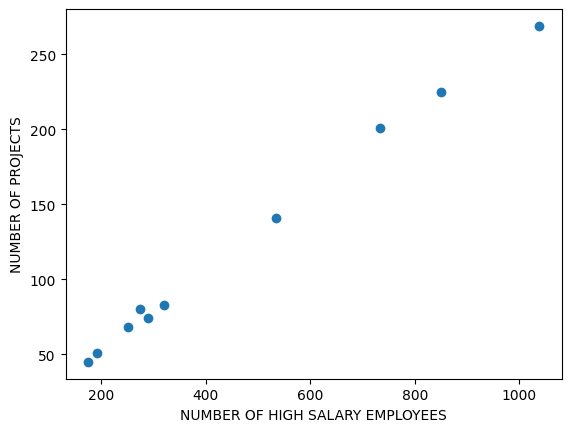

In [19]:
plt.scatter(HR_CORR_PROJECTS_SALARY_CAT['high_x'],HR_CORR_PROJECTS_SALARY_CAT['high_y'])
plt.ylabel('NUMBER OF PROJECTS')
plt.xlabel('NUMBER OF HIGH SALARY EMPLOYEES') 

Text(0.5, 0, 'NUMBER OF MEDIUM SALARY EMPLOYEES')

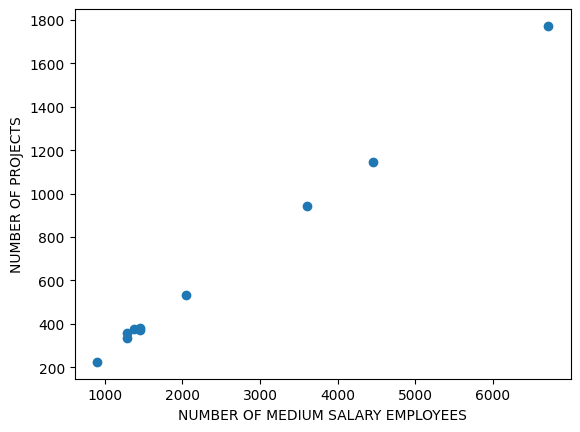

In [20]:
plt.scatter(HR_CORR_PROJECTS_SALARY_CAT['medium_x'],HR_CORR_PROJECTS_SALARY_CAT['medium_y'])
plt.ylabel('NUMBER OF PROJECTS')
plt.xlabel('NUMBER OF MEDIUM SALARY EMPLOYEES') 

Text(0.5, 0, 'NUMBER OF LOW SALARY EMPLOYEES')

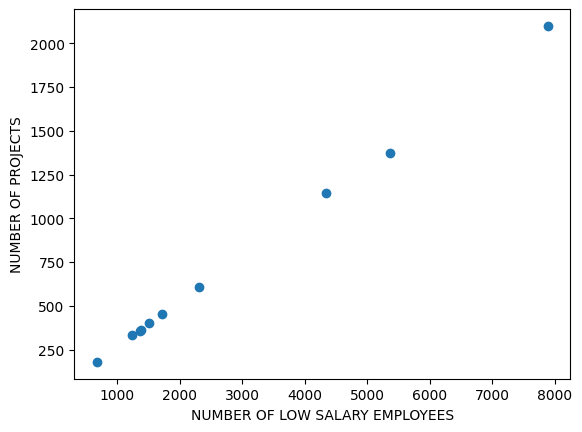

In [21]:
plt.scatter(HR_CORR_PROJECTS_SALARY_CAT['low_x'],HR_CORR_PROJECTS_SALARY_CAT['low_y'])
plt.ylabel('NUMBER OF PROJECTS')
plt.xlabel('NUMBER OF LOW SALARY EMPLOYEES') 

In [24]:
ALL_PROJECT_BY_DEPARTMENT = HR.groupby(['Department'])['number_project'].sum()
ALL_PROJECT_BY_DEPARTMENT

Department
IT              4683
RandD           3033
accounting      2934
hr              2701
management      2432
marketing       3164
product_mng     3434
sales          15634
support         8479
technical      10548
Name: number_project, dtype: int64

In [26]:
# Reset index to make 'Department' a regular column
ALL_PROJECT_BY_DEPARTMENT = ALL_PROJECT_BY_DEPARTMENT.reset_index()

# Now you can merge with the other DataFrame
HR_CORR_ALL_PROJECTS_SALARY_CAT = ALL_PROJECT_BY_DEPARTMENT.merge(HR_SALARY_CAT_BY_DEPARTMENT, how='inner', on='Department')

# Display the result
HR_CORR_ALL_PROJECTS_SALARY_CAT

,Department,number_project,high,low,medium
0,IT,4683,83,609,535
1,RandD,3033,51,364,372
2,accounting,2934,74,358,335
3,hr,2701,45,335,359
4,management,2432,225,180,225
5,marketing,3164,80,402,376
6,product_mng,3434,68,451,383
7,sales,15634,269,2099,1772
8,support,8479,141,1146,942
9,technical,10548,201,1372,1147


Text(0.5, 0, 'NUMBER OF ALL PROJECTS')

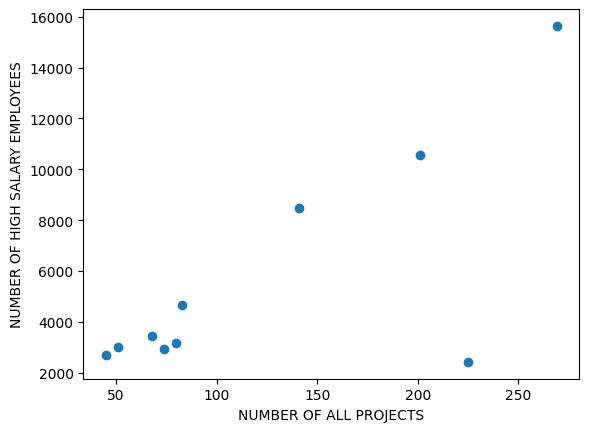

In [27]:
plt.scatter(HR_CORR_ALL_PROJECTS_SALARY_CAT['high'],HR_CORR_ALL_PROJECTS_SALARY_CAT['number_project'])
plt.ylabel('NUMBER OF HIGH SALARY EMPLOYEES')
plt.xlabel('NUMBER OF ALL PROJECTS') 

In [28]:
HR_CORR_ALL_PROJECTS_SALARY_CAT['high'].corr(HR_CORR_ALL_PROJECTS_SALARY_CAT['number_project'])

np.float64(0.7415307148631972)

Text(0.5, 0, 'NUMBER OF ALL PROJECTS')

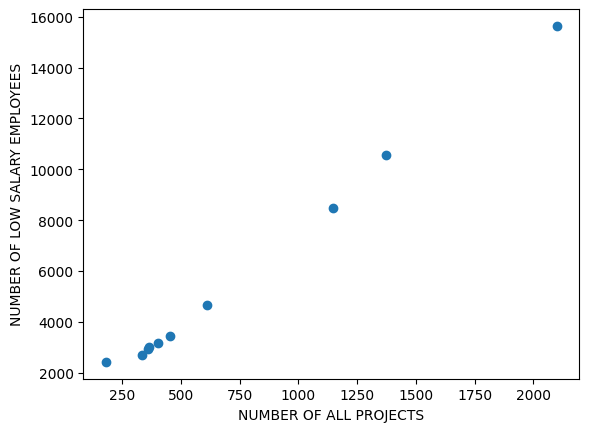

In [29]:
plt.scatter(HR_CORR_ALL_PROJECTS_SALARY_CAT['low'],HR_CORR_ALL_PROJECTS_SALARY_CAT['number_project'])
plt.ylabel('NUMBER OF LOW SALARY EMPLOYEES')
plt.xlabel('NUMBER OF ALL PROJECTS') 

In [30]:
HR_CORR_ALL_PROJECTS_SALARY_CAT['low'].corr(HR_CORR_ALL_PROJECTS_SALARY_CAT['number_project'])

np.float64(0.9979290105431939)

Text(0.5, 0, 'NUMBER OF ALL PROJECTS')

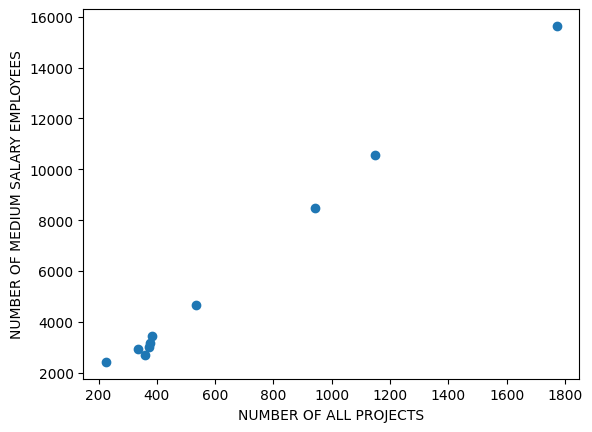

In [31]:
plt.scatter(HR_CORR_ALL_PROJECTS_SALARY_CAT['medium'],HR_CORR_ALL_PROJECTS_SALARY_CAT['number_project'])
plt.ylabel('NUMBER OF MEDIUM SALARY EMPLOYEES')
plt.xlabel('NUMBER OF ALL PROJECTS') 

In [32]:
HR_CORR_ALL_PROJECTS_SALARY_CAT['medium'].corr(HR_CORR_ALL_PROJECTS_SALARY_CAT['number_project'])

np.float64(0.9981030222909676)

In [ ]:
with pd.ExcelWriter('HR_Python.xlsx', engine = 'openpyxl') as writer:
    HR_DEPARTMENT_SALARY_MEAN.to_excel(writer, sheet_name = 'HR_DEPARTMENT_SALARY_MEAN')
    HR_SALARY_MEAN.to_excel(writer, sheet_name = 'HR_SALARY_MEAN')
    HR_DEPARTMENT_MEAN.to_excel(writer, sheet_name ='HR_DEPARTMENT_MEAN')
    HR_SALARY_CAT_BY_DEPARTMENT.to_excel(writer, sheet_name = 'HR_SALARY_CAT_BY_DEPARTMENT')
    HR_SALARY_CAT_IN_DEPARTMENT.to_excel(writer, sheet_name = 'HR_SALARY_CAT_IN_DEPARTMENT')
    HR_NUMBER_OF_PROJECTS_BY_DEPARTMENT.to_excel(writer, sheet_name = 'HR_NUMBER_OF_PROJECTS_BY_DEPARTMENT')